# Stage 3: Baseline Simulation Audit

This notebook validates integrity, distributions, treatment-group imbalance,
propensity overlap, confounding bias, heterogeneous effects, and policy value.
Columns beginning with true_ are oracle-only and must never be model features.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
PROJECT_ROOT = HERE if (HERE / "src" / "simulation.py").exists() else HERE.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from simulation import MODEL_FEATURES, ORACLE_COLUMNS, simulate_customers

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

RETENTION_VALUE = 80.0
TREATMENT_COST = 10.0
POLICY_CAPACITY = 0.20

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Samridh\Projects\Causal_Inference


## 1. Generate the reproducible baseline cohort

In [2]:
data = simulate_customers(number_of_customers=20_000, seed=42)
print(f"Shape: {data.shape}")
data.head()

Shape: (20000, 16)


,customer_id,tenure_months,plan_type,monthly_price,login_days_30d,usage_trend_90d,support_tickets_30d,late_payments_12m,region,device_type,treatment,retained_90d,true_propensity,true_mu0,true_mu1,true_cate
0,1,37,standard,52.9800,16,-0.2490,1,1,south,tablet,0,0,0.4562,0.4084,0.7067,0.2983
1,2,49,basic,20.2900,21,-0.2860,2,2,south,desktop,1,1,0.4993,0.3806,0.7322,0.3516
2,3,33,basic,26.3600,20,-0.0540,4,0,north,mobile,1,0,0.5236,0.3977,0.6671,0.2693
3,4,30,premium,87.2800,19,-0.0090,1,0,east,tablet,0,1,0.3365,0.6923,0.8301,0.1378
4,5,54,standard,49.9100,23,0.2600,1,0,south,mobile,0,1,0.1605,0.8332,0.8968,0.0637


## 2. Dataset integrity

Stop the analysis if any of these checks fails.

In [3]:
expected_columns = {
    "customer_id",
    *MODEL_FEATURES,
    "treatment",
    "retained_90d",
    *ORACLE_COLUMNS,
}

integrity_checks = {
    "expected columns present": expected_columns.issubset(data.columns),
    "customer IDs unique": data["customer_id"].is_unique,
    "no missing values": not data.isna().any().any(),
    "tenure within 1-120": data["tenure_months"].between(1, 120).all(),
    "login days within 0-30": data["login_days_30d"].between(0, 30).all(),
    "usage trend within -1 to 1": data["usage_trend_90d"].between(-1, 1).all(),
    "support tickets within 0-10": data["support_tickets_30d"].between(0, 10).all(),
    "late payments within 0-12": data["late_payments_12m"].between(0, 12).all(),
    "binary treatment": set(data["treatment"].unique()).issubset({0, 1}),
    "binary outcome": set(data["retained_90d"].unique()).issubset({0, 1}),
    "valid propensity": data["true_propensity"].between(0, 1).all(),
    "valid outcome probabilities": (
        data["true_mu0"].between(0, 1).all()
        and data["true_mu1"].between(0, 1).all()
    ),
}
integrity_table = pd.DataFrame(
    {"check": integrity_checks.keys(), "passed": integrity_checks.values()}
)
display(integrity_table)
assert integrity_table["passed"].all(), "At least one integrity check failed."

,check,passed
0,expected columns present,True
1,customer IDs unique,True
2,no missing values,True
3,tenure within 1-120,True
4,login days within 0-30,True
5,usage trend within -1 to 1,True
6,support tickets within 0-10,True
7,late payments within 0-12,True
8,binary treatment,True
9,binary outcome,True


## 3. Population distributions

In [4]:
numeric_columns = [
    "tenure_months",
    "monthly_price",
    "login_days_30d",
    "usage_trend_90d",
    "support_tickets_30d",
    "late_payments_12m",
]
categorical_columns = ["plan_type", "region", "device_type"]

display(data[numeric_columns].describe().T)
for column in categorical_columns:
    print(f"\n{column}")
    display(data[column].value_counts(normalize=True).rename("share").to_frame())

,count,mean,std,min,25%,50%,75%,max
tenure_months,"20,000.0000",35.2833,23.5115,1.0000,18.0000,30.0000,47.0000,120.0000
monthly_price,"20,000.0000",50.1676,23.3541,10.9100,27.3800,48.7700,77.0025,99.5100
login_days_30d,"20,000.0000",17.8848,4.3845,5.0000,15.0000,18.0000,21.0000,30.0000
usage_trend_90d,"20,000.0000",0.0508,0.3565,-1.0000,-0.1930,0.0540,0.2920,1.0000
support_tickets_30d,"20,000.0000",0.6976,0.8646,0.0000,0.0000,0.0000,1.0000,7.0000
late_payments_12m,"20,000.0000",0.3629,0.6105,0.0000,0.0000,0.0000,1.0000,4.0000



plan_type


,share
plan_type,
standard,0.3946
basic,0.3500
premium,0.2554



region


,share
region,
south,0.2953
east,0.2521
north,0.2514
west,0.2013



device_type


,share
device_type,
mobile,0.6039
desktop,0.2962
tablet,0.0999


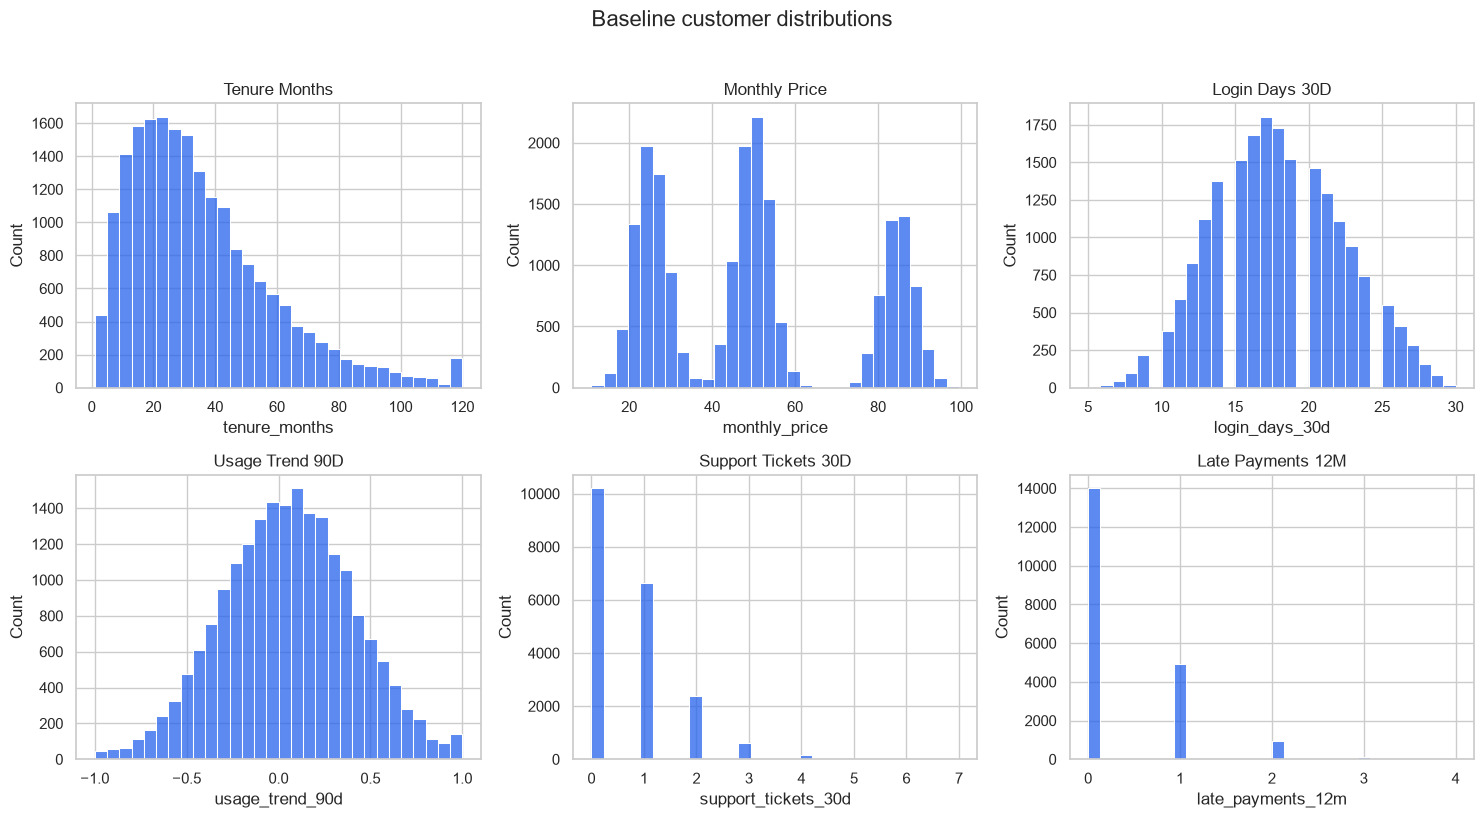

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, numeric_columns):
    sns.histplot(data=data, x=column, bins=30, ax=axis, color="#2563EB")
    axis.set_title(column.replace("_", " ").title())
fig.suptitle("Baseline customer distributions", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "customer_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

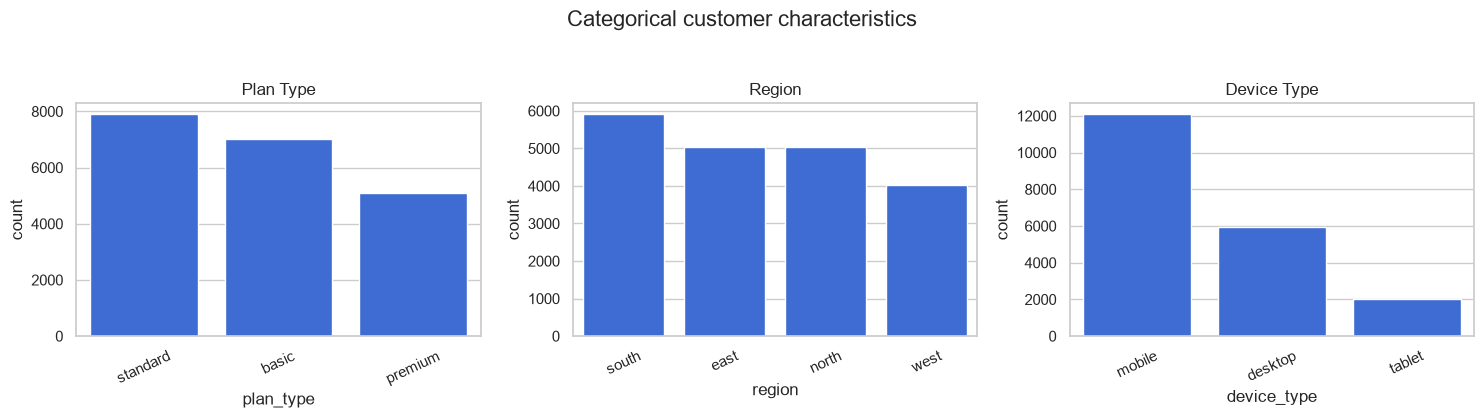

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, categorical_columns):
    order = data[column].value_counts().index
    sns.countplot(data=data, x=column, order=order, ax=axis, color="#2563EB")
    axis.set_title(column.replace("_", " ").title())
    axis.tick_params(axis="x", rotation=25)
fig.suptitle("Categorical customer characteristics", fontsize=16, y=1.04)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "categorical_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Treatment-group balance

Absolute standardized mean differences above 0.10 indicate meaningful
imbalance. Some imbalance is expected because assignment is confounded.

In [7]:
def standardized_mean_difference(values: pd.Series, treatment: pd.Series) -> float:
    treated = values[treatment == 1].astype(float)
    untreated = values[treatment == 0].astype(float)
    pooled_variance = (treated.var(ddof=1) + untreated.var(ddof=1)) / 2
    if pooled_variance == 0:
        return 0.0
    return float((treated.mean() - untreated.mean()) / np.sqrt(pooled_variance))


balance_features = pd.concat(
    [
        data[numeric_columns],
        pd.get_dummies(data[categorical_columns], dtype=float),
    ],
    axis=1,
)
balance_table = pd.DataFrame(
    {
        "feature": balance_features.columns,
        "smd": [
            standardized_mean_difference(balance_features[column], data["treatment"])
            for column in balance_features.columns
        ],
    }
)
balance_table["absolute_smd"] = balance_table["smd"].abs()
balance_table = balance_table.sort_values("absolute_smd", ascending=False)
display(balance_table)

,feature,smd,absolute_smd
4,support_tickets_30d,0.4083,0.4083
2,login_days_30d,-0.3877,0.3877
3,usage_trend_90d,-0.3672,0.3672
0,tenure_months,-0.2681,0.2681
5,late_payments_12m,0.2340,0.2340
6,plan_type_basic,0.1355,0.1355
1,monthly_price,-0.1162,0.1162
7,plan_type_premium,-0.0754,0.0754
8,plan_type_standard,-0.0666,0.0666
13,device_type_desktop,-0.0295,0.0295


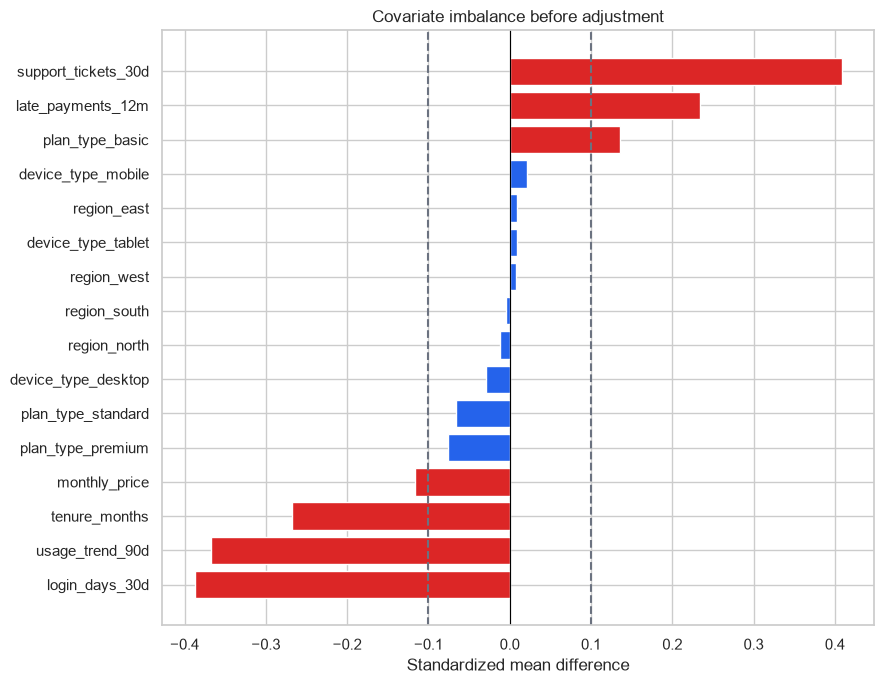

In [8]:
plot_balance = balance_table.sort_values("smd")
fig, axis = plt.subplots(figsize=(9, 7))
colors = np.where(plot_balance["absolute_smd"] >= 0.10, "#DC2626", "#2563EB")
axis.barh(plot_balance["feature"], plot_balance["smd"], color=colors)
axis.axvline(0, color="black", linewidth=0.8)
axis.axvline(0.10, color="#6B7280", linestyle="--")
axis.axvline(-0.10, color="#6B7280", linestyle="--")
axis.set(
    title="Covariate imbalance before adjustment",
    xlabel="Standardized mean difference",
    ylabel="",
)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "covariate_balance.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. True propensity overlap

True propensity is available only for simulator validation. With real data,
propensity must be estimated from pre-treatment variables.

,count,mean,std,min,max
treatment,,,,,
untreated,14030,0.2699,0.1245,0.0500,0.8000
treated,5970,0.3630,0.1568,0.0500,0.8000


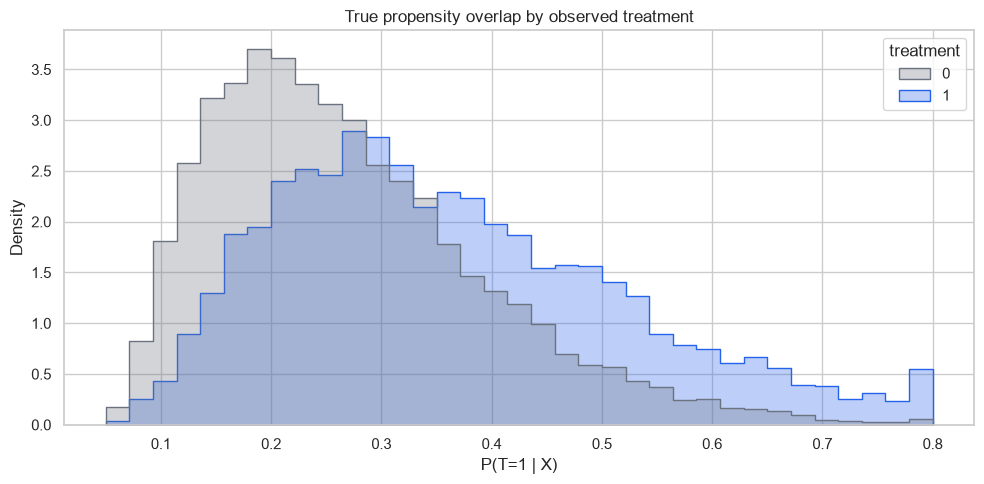

In [9]:
overlap_summary = (
    data.groupby("treatment")["true_propensity"]
    .agg(["count", "mean", "std", "min", "max"])
    .rename(index={0: "untreated", 1: "treated"})
)
display(overlap_summary)

fig, axis = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=data,
    x="true_propensity",
    hue="treatment",
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.30,
    palette={0: "#6B7280", 1: "#2563EB"},
    ax=axis,
)
axis.set(
    title="True propensity overlap by observed treatment",
    xlabel="P(T=1 | X)",
    ylabel="Density",
)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "propensity_overlap.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Naive association versus true causal effect

,estimate,effect
0,Naive difference,0.0452
1,True ATE,0.1557


Naive bias: -0.1106 (-11.06 percentage points)


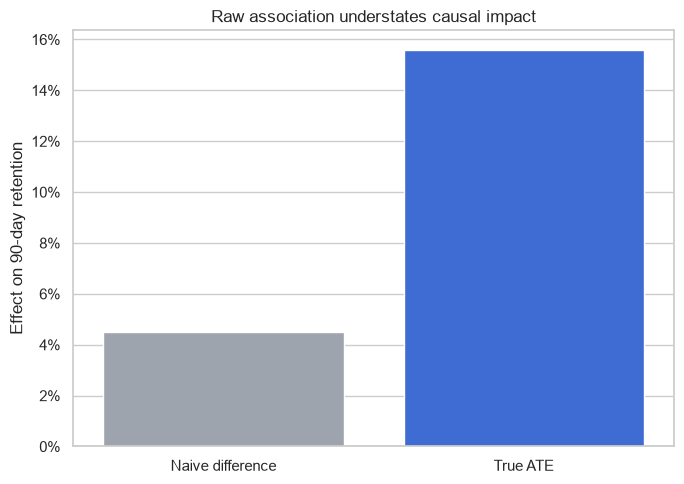

In [10]:
naive_effect = (
    data.loc[data["treatment"] == 1, "retained_90d"].mean()
    - data.loc[data["treatment"] == 0, "retained_90d"].mean()
)
true_ate = data["true_cate"].mean()
naive_bias = naive_effect - true_ate

effect_comparison = pd.DataFrame(
    {
        "estimate": ["Naive difference", "True ATE"],
        "effect": [naive_effect, true_ate],
    }
)
display(effect_comparison)
print(f"Naive bias: {naive_bias:.4f} ({naive_bias * 100:.2f} percentage points)")

fig, axis = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=effect_comparison,
    x="estimate",
    y="effect",
    hue="estimate",
    legend=False,
    palette=["#9CA3AF", "#2563EB"],
    ax=axis,
)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(
    title="Raw association understates causal impact",
    xlabel="",
    ylabel="Effect on 90-day retention",
)
axis.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "naive_vs_true_effect.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Treatment-effect heterogeneity

The expected pattern is a persuadable middle: moderately declining customers
benefit more than healthy or severely disengaged customers.

In [11]:
data = data.copy()
data["usage_segment"] = pd.cut(
    data["usage_trend_90d"],
    bins=[-1.01, -0.50, -0.10, 0.25, 1.01],
    labels=["severely declining", "moderately declining", "stable", "growing"],
)
cate_by_usage = (
    data.groupby("usage_segment", observed=True)["true_cate"]
    .agg(["mean", "std", "count"])
)
cate_by_plan = data.groupby("plan_type")["true_cate"].agg(["mean", "std", "count"])
cate_by_support = (
    data.assign(high_support_need=data["support_tickets_30d"] >= 3)
    .groupby("high_support_need")["true_cate"]
    .agg(["mean", "std", "count"])
)

print("CATE by usage segment")
display(cate_by_usage)
print("CATE by plan")
display(cate_by_plan)
print("CATE by support need")
display(cate_by_support)

CATE by usage segment


,mean,std,count
usage_segment,,,
severely declining,0.1622,0.0737,1225
moderately declining,0.2466,0.0841,5520
stable,0.1612,0.0809,7447
growing,0.0610,0.0498,5808


CATE by plan


,mean,std,count
plan_type,,,
basic,0.2251,0.0895,7001
premium,0.0749,0.0692,5107
standard,0.1465,0.0861,7892


CATE by support need


,mean,std,count
high_support_need,,,
False,0.1563,0.1022,19218
True,0.1421,0.0878,782


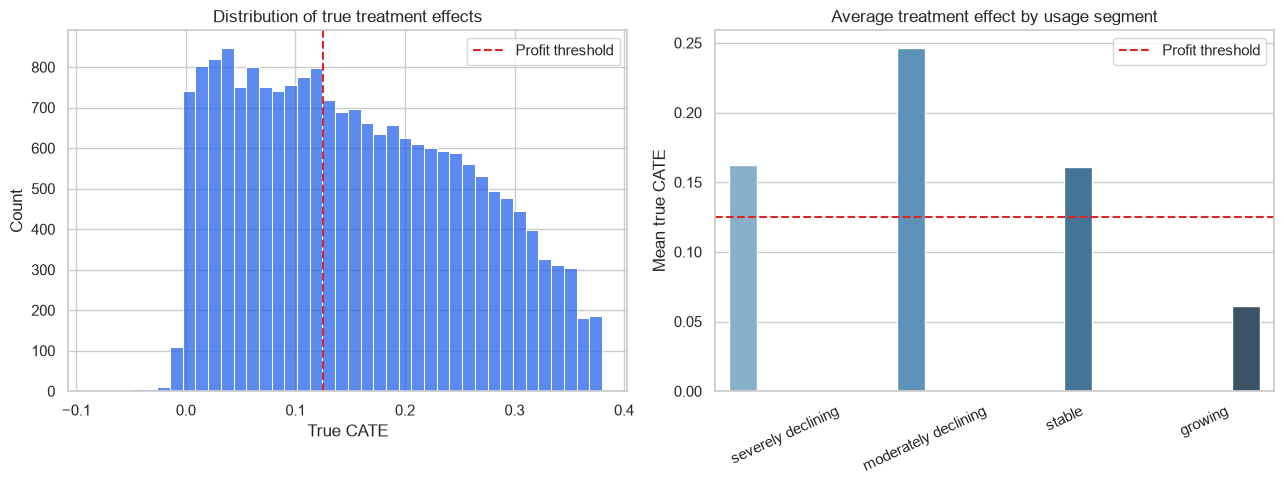

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=data, x="true_cate", bins=40, color="#2563EB", ax=axes[0])
axes[0].axvline(
    TREATMENT_COST / RETENTION_VALUE,
    color="#DC2626",
    linestyle="--",
    label="Profit threshold",
)
axes[0].set(title="Distribution of true treatment effects", xlabel="True CATE")
axes[0].legend()

sns.barplot(
    data=cate_by_usage.reset_index(),
    x="usage_segment",
    y="mean",
    hue="usage_segment",
    legend=False,
    palette="Blues_d",
    ax=axes[1],
)
axes[1].axhline(
    TREATMENT_COST / RETENTION_VALUE,
    color="#DC2626",
    linestyle="--",
    label="Profit threshold",
)
axes[1].set(
    title="Average treatment effect by usage segment",
    xlabel="",
    ylabel="Mean true CATE",
)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / "cate_heterogeneity.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Policy opportunity

Treatment is profitable when 80 times CATE minus 10 is positive, so CATE must
exceed 0.125. The oracle treats up to the top 20% by true incremental value.

In [13]:
data["true_incremental_value"] = (
    RETENTION_VALUE * data["true_cate"] - TREATMENT_COST
)
data["profitable_to_treat"] = data["true_incremental_value"] > 0
maximum_treated = int(np.floor(len(data) * POLICY_CAPACITY))

oracle_candidates = data.nlargest(maximum_treated, "true_incremental_value")
oracle_treated = oracle_candidates[
    oracle_candidates["true_incremental_value"] > 0
]
policy_summary = pd.Series(
    {
        "profitability threshold (CATE)": TREATMENT_COST / RETENTION_VALUE,
        "profitable customer share": data["profitable_to_treat"].mean(),
        "maximum customers treatable": maximum_treated,
        "oracle customers treated": len(oracle_treated),
        "oracle mean CATE": oracle_treated["true_cate"].mean(),
        "oracle incremental retained customers": oracle_treated["true_cate"].sum(),
        "oracle total incremental profit": oracle_treated["true_incremental_value"].sum(),
        "oracle profit per treated customer": oracle_treated["true_incremental_value"].mean(),
    }
)
display(policy_summary.to_frame("value"))

,value
profitability threshold (CATE),0.1250
profitable customer share,0.5636
maximum customers treatable,"4,000.0000"
oracle customers treated,"4,000.0000"
oracle mean CATE,0.3067
oracle incremental retained customers,"1,226.8066"
oracle total incremental profit,"58,144.5279"
oracle profit per treated customer,14.5361


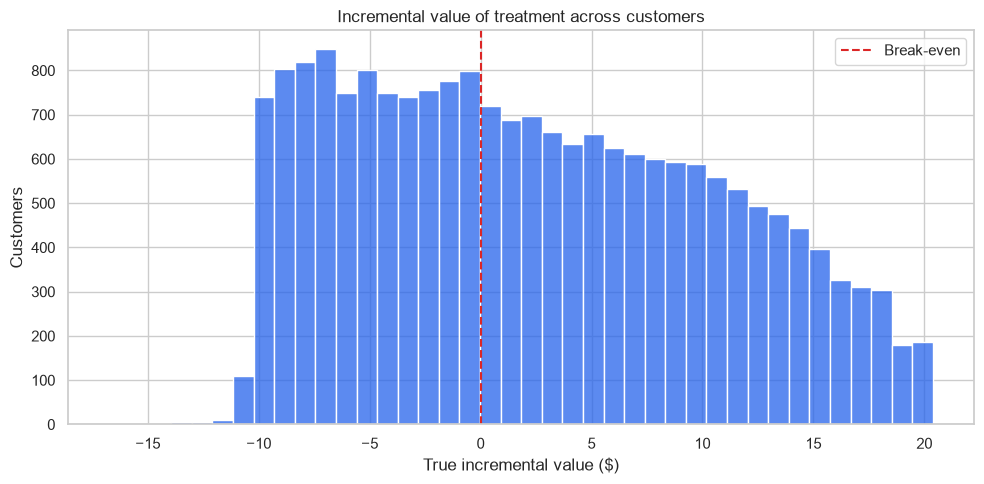

In [14]:
fig, axis = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=data,
    x="true_incremental_value",
    bins=40,
    color="#2563EB",
    ax=axis,
)
axis.axvline(0, color="#DC2626", linestyle="--", label="Break-even")
axis.set(
    title="Incremental value of treatment across customers",
    xlabel="True incremental value ($)",
    ylabel="Customers",
)
axis.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "incremental_value_distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 9. Acceptance decision

In [15]:
acceptance_checks = {
    "all integrity checks pass": bool(integrity_table["passed"].all()),
    "treatment rate is 20%-45%": 0.20 <= data["treatment"].mean() <= 0.45,
    "retention rate is 45%-85%": 0.45 <= data["retained_90d"].mean() <= 0.85,
    "important imbalance exists": balance_table["absolute_smd"].max() >= 0.10,
    "propensity remains within bounds": data["true_propensity"].between(0.05, 0.80).all(),
    "naive bias is meaningful": abs(naive_bias) >= 0.02,
    "CATE is heterogeneous": data["true_cate"].std() > 0.02,
    "at least 20% are profitable": data["profitable_to_treat"].mean() >= POLICY_CAPACITY,
    "capacity is binding": data["profitable_to_treat"].sum() > maximum_treated,
}
acceptance_table = pd.DataFrame(
    {"criterion": acceptance_checks.keys(), "passed": acceptance_checks.values()}
)
display(acceptance_table)

if acceptance_table["passed"].all():
    print("DECISION: ACCEPT the baseline simulator for causal-model benchmarking.")
else:
    failed = acceptance_table.loc[
        ~acceptance_table["passed"], "criterion"
    ].tolist()
    print("DECISION: RECALIBRATE the simulator before Stage 4.")
    print("Failed criteria:", failed)

,criterion,passed
0,all integrity checks pass,True
1,treatment rate is 20%-45%,True
2,retention rate is 45%-85%,True
3,important imbalance exists,True
4,propensity remains within bounds,True
5,naive bias is meaningful,True
6,CATE is heterogeneous,True
7,at least 20% are profitable,True
8,capacity is binding,True


DECISION: ACCEPT the baseline simulator for causal-model benchmarking.


## 10. Interpretation checklist

Use these outputs in the written audit report:

1. Which characteristics are most imbalanced?
2. Is propensity overlap adequate?
3. Why does the naive estimate differ from the true ATE?
4. Which segments respond most strongly?
5. Why does the 20% capacity create a ranking problem?
6. What limitations arise from simulated data?